In [1]:
# Cell 1 — AIS input discovery and configuration

from pathlib import Path
import pandas as pd

BASE = Path("/Volumes/Utkash SSD/SIH26143")

# Phase 3 output
PHASE3_RESULT_PATH = BASE / "phase3_hindcast_result.json"

# Expected AIS fields
AIS_REQUIRED_COLUMNS = [
    "mmsi",
    "timestamp",
    "latitude",
    "longitude",
    "sog",
    "cog",
]

AIS_OPTIONAL_COLUMNS = [
    "heading",
    "nav_status",
    "vessel_name",
    "imo",
    "ship_type",
    "draught",
]

# Search project directory for likely AIS files
ais_candidates = []

for path in BASE.rglob("*"):
    if path.is_file():
        name = path.name.lower()

        if (
            "ais" in name
            or "vessel" in name
            or "ship" in name
        ):
            ais_candidates.append(path)

print("AIS candidate files found:")
print("-" * 50)

if ais_candidates:
    for path in ais_candidates:
        print(path)
else:
    print("No AIS dataset found in project directory.")

print("\nRequired AIS fields:")
print(AIS_REQUIRED_COLUMNS)

print("\nOptional AIS fields:")
print(AIS_OPTIONAL_COLUMNS)

print("\nPhase 3 result exists:")
print(PHASE3_RESULT_PATH.exists())

AIS candidate files found:
--------------------------------------------------
/Volumes/Utkash SSD/SIH26143/phase4_ais_attribution_result.json

Required AIS fields:
['mmsi', 'timestamp', 'latitude', 'longitude', 'sog', 'cog']

Optional AIS fields:
['heading', 'nav_status', 'vessel_name', 'imo', 'ship_type', 'draught']

Phase 3 result exists:
True


In [2]:
# Cell 2 — AIS attribution configuration

import json
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path("/Volumes/Utkash SSD/SIH26143")

# Load Phase 3 hindcast result
with open(BASE / "phase3_hindcast_result.json", "r") as f:
    phase3_result = json.load(f)

# Probable origin
origin_center_lat = phase3_result["ensemble_origin"]["latitude"]
origin_center_lon = phase3_result["ensemble_origin"]["longitude"]

origin_bounds = phase3_result["probable_origin_region"]

# Observation
observation_time = pd.Timestamp(
    phase3_result["observation"]["timestamp"]
)

# AIS investigation window
AIS_LOOKBACK_HOURS = 24
AIS_LOOKAHEAD_HOURS = 6

ais_start_time = (
    observation_time
    - pd.Timedelta(hours=AIS_LOOKBACK_HOURS)
)

ais_end_time = (
    observation_time
    + pd.Timedelta(hours=AIS_LOOKAHEAD_HOURS)
)

# Spatial search buffer around probable origin
ORIGIN_BUFFER_KM = 15.0

# Candidate filtering
MAX_CANDIDATE_DISTANCE_KM = 20.0

# AIS sampling interval
AIS_INTERVAL_MINUTES = 10

print("AIS investigation configuration")
print("=" * 50)

print(
    f"Origin center : "
    f"{origin_center_lat:.6f}, "
    f"{origin_center_lon:.6f}"
)

print(
    f"Origin region : "
    f"{origin_bounds['min_latitude']:.6f} → "
    f"{origin_bounds['max_latitude']:.6f} N"
)

print(
    f"                "
    f"{origin_bounds['min_longitude']:.6f} → "
    f"{origin_bounds['max_longitude']:.6f} E"
)

print(f"\nAIS window:")
print(f"Start: {ais_start_time}")
print(f"End  : {ais_end_time}")

print(f"\nSpatial buffer: {ORIGIN_BUFFER_KM} km")
print(f"Candidate distance threshold: {MAX_CANDIDATE_DISTANCE_KM} km")
print(f"AIS interval: {AIS_INTERVAL_MINUTES} minutes")

AIS investigation configuration
Origin center : 32.475501, 30.262603
Origin region : 32.459423 → 32.493904 N
                30.243041 → 30.283669 E

AIS window:
Start: 2019-10-18 15:56:47+00:00
End  : 2019-10-19 21:56:47+00:00

Spatial buffer: 15.0 km
Candidate distance threshold: 20.0 km
AIS interval: 10 minutes


In [3]:
# Cell 3 — Generate synthetic AIS trajectories
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd

np.random.seed(42)

# ---------------------------------------------------------
# Synthetic scenario parameters
# ---------------------------------------------------------

AIS_START = ais_start_time
AIS_END = ais_end_time

AIS_TIMES = pd.date_range(
    start=AIS_START,
    end=AIS_END,
    freq=f"{AIS_INTERVAL_MINUTES}min",
    tz="UTC"
)

NUM_VESSELS = 12

# Synthetic spill-release time used ONLY to construct
# the demonstration dataset.
#
# The attribution algorithm will NOT use this value.
SYNTHETIC_RELEASE_TIME = (
    observation_time - pd.Timedelta(hours=18)
)

# Probable origin center from Phase 3
TARGET_LAT = float(origin_center_lat)
TARGET_LON = float(origin_center_lon)


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two coordinates."""

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


def calculate_cog(lat1, lon1, lat2, lon2):
    """Calculate course over ground in degrees."""

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)

    x = np.sin(dlon) * np.cos(lat2)

    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1)
        * np.cos(lat2)
        * np.cos(dlon)
    )

    bearing = np.degrees(
        np.arctan2(x, y)
    )

    return (bearing + 360) % 360


# ---------------------------------------------------------
# Vessel definitions
# ---------------------------------------------------------

vessel_types = [
    "Tanker",
    "Tanker",
    "Tanker",
    "Cargo",
    "Cargo",
    "Cargo",
    "Fishing",
    "Fishing",
    "Container",
    "Service",
    "Cargo",
    "Tanker",
]

vessel_mmsis = [
    620100001 + i
    for i in range(NUM_VESSELS)
]

# ---------------------------------------------------------
# Create vessel trajectories
# ---------------------------------------------------------

ais_records = []

total_minutes = (
    (AIS_END - AIS_START).total_seconds()
    / 60
)

release_fraction = (
    (SYNTHETIC_RELEASE_TIME - AIS_START).total_seconds()
    / (AIS_END - AIS_START).total_seconds()
)

for vessel_idx in range(NUM_VESSELS):

    mmsi = vessel_mmsis[vessel_idx]
    vessel_type = vessel_types[vessel_idx]

    # -----------------------------------------------------
    # Vessel 0: trajectory intentionally passes through
    # probable origin region around the synthetic release
    # time.
    #
    # This is ground truth ONLY for evaluation.
    # -----------------------------------------------------

    if vessel_idx == 0:

        start_lat = TARGET_LAT - 0.12
        start_lon = TARGET_LON - 0.18

        end_lat = TARGET_LAT + 0.12
        end_lon = TARGET_LON + 0.18

    # -----------------------------------------------------
    # Other vessels: independent routes near the region
    # -----------------------------------------------------

    else:

        angle = (
            2 * np.pi * vessel_idx / (NUM_VESSELS - 1)
        )

        distance = (
            0.08
            + 0.08
            * np.random.random()
        )

        center_lat = (
            TARGET_LAT
            + distance * np.sin(angle)
        )

        center_lon = (
            TARGET_LON
            + distance * np.cos(angle)
        )

        route_angle = (
            angle
            + np.pi / 2
            + np.random.normal(0, 0.25)
        )

        route_length = 0.20

        start_lat = (
            center_lat
            - route_length
            * np.sin(route_angle)
        )

        start_lon = (
            center_lon
            - route_length
            * np.cos(route_angle)
        )

        end_lat = (
            center_lat
            + route_length
            * np.sin(route_angle)
        )

        end_lon = (
            center_lon
            + route_length
            * np.cos(route_angle)
        )

    # -----------------------------------------------------
    # Interpolate trajectory
    # -----------------------------------------------------

    for i, timestamp in enumerate(AIS_TIMES):

        fraction = (
            timestamp - AIS_START
        ).total_seconds() / (
            AIS_END - AIS_START
        ).total_seconds()

        fraction = np.clip(
            fraction,
            0,
            1
        )

        lat = (
            start_lat
            + fraction
            * (end_lat - start_lat)
        )

        lon = (
            start_lon
            + fraction
            * (end_lon - start_lon)
        )

        # Small measurement-like noise
        if vessel_idx != 0:
            lat += np.random.normal(0, 0.00015)
            lon += np.random.normal(0, 0.00015)

        # Previous point for SOG/COG
        if i == 0:

            sog_knots = 0.0
            cog = 0.0

        else:

            prev_timestamp = AIS_TIMES[i - 1]

            prev_fraction = (
                prev_timestamp - AIS_START
            ).total_seconds() / (
                AIS_END - AIS_START
            ).total_seconds()

            prev_lat = (
                start_lat
                + prev_fraction
                * (end_lat - start_lat)
            )

            prev_lon = (
                start_lon
                + prev_fraction
                * (end_lon - start_lon)
            )

            distance_km = haversine_km(
                prev_lat,
                prev_lon,
                lat,
                lon
            )

            dt_hours = (
                timestamp - prev_timestamp
            ).total_seconds() / 3600

            speed_kmh = (
                distance_km / dt_hours
                if dt_hours > 0
                else 0
            )

            # km/h → knots
            sog_knots = (
                speed_kmh / 1.852
            )

            cog = calculate_cog(
                prev_lat,
                prev_lon,
                lat,
                lon
            )

        ais_records.append({
            "mmsi": mmsi,
            "timestamp": timestamp,
            "latitude": lat,
            "longitude": lon,
            "sog": sog_knots,
            "cog": cog,
            "ship_type": vessel_type,
        })


synthetic_ais_df = pd.DataFrame(
    ais_records
)

print("Synthetic AIS generated")
print("=" * 50)

print("Rows:", len(synthetic_ais_df))
print("Vessels:", synthetic_ais_df["mmsi"].nunique())

print(
    "Time range:",
    synthetic_ais_df["timestamp"].min(),
    "→",
    synthetic_ais_df["timestamp"].max()
)

print("\nVessel types:")
print(
    synthetic_ais_df[
        ["mmsi", "ship_type"]
    ].drop_duplicates()
)

print("\nSample:")
print(
    synthetic_ais_df.head(10)
)

Synthetic AIS generated
Rows: 2172
Vessels: 12
Time range: 2019-10-18 15:56:47+00:00 → 2019-10-19 21:56:47+00:00

Vessel types:
           mmsi  ship_type
0     620100001     Tanker
181   620100002     Tanker
362   620100003     Tanker
543   620100004      Cargo
724   620100005      Cargo
905   620100006      Cargo
1086  620100007    Fishing
1267  620100008    Fishing
1448  620100009  Container
1629  620100010    Service
1810  620100011      Cargo
1991  620100012     Tanker

Sample:
        mmsi                 timestamp   latitude  longitude       sog  \
0  620100001 2019-10-18 15:56:47+00:00  32.355501  30.082603  0.000000   
1  620100001 2019-10-18 16:06:47+00:00  32.356834  30.084603  0.775326   
2  620100001 2019-10-18 16:16:47+00:00  32.358168  30.086603  0.775319   
3  620100001 2019-10-18 16:26:47+00:00  32.359501  30.088603  0.775312   
4  620100001 2019-10-18 16:36:47+00:00  32.360834  30.090603  0.775305   
5  620100001 2019-10-18 16:46:47+00:00  32.362168  30.092603  0.7752

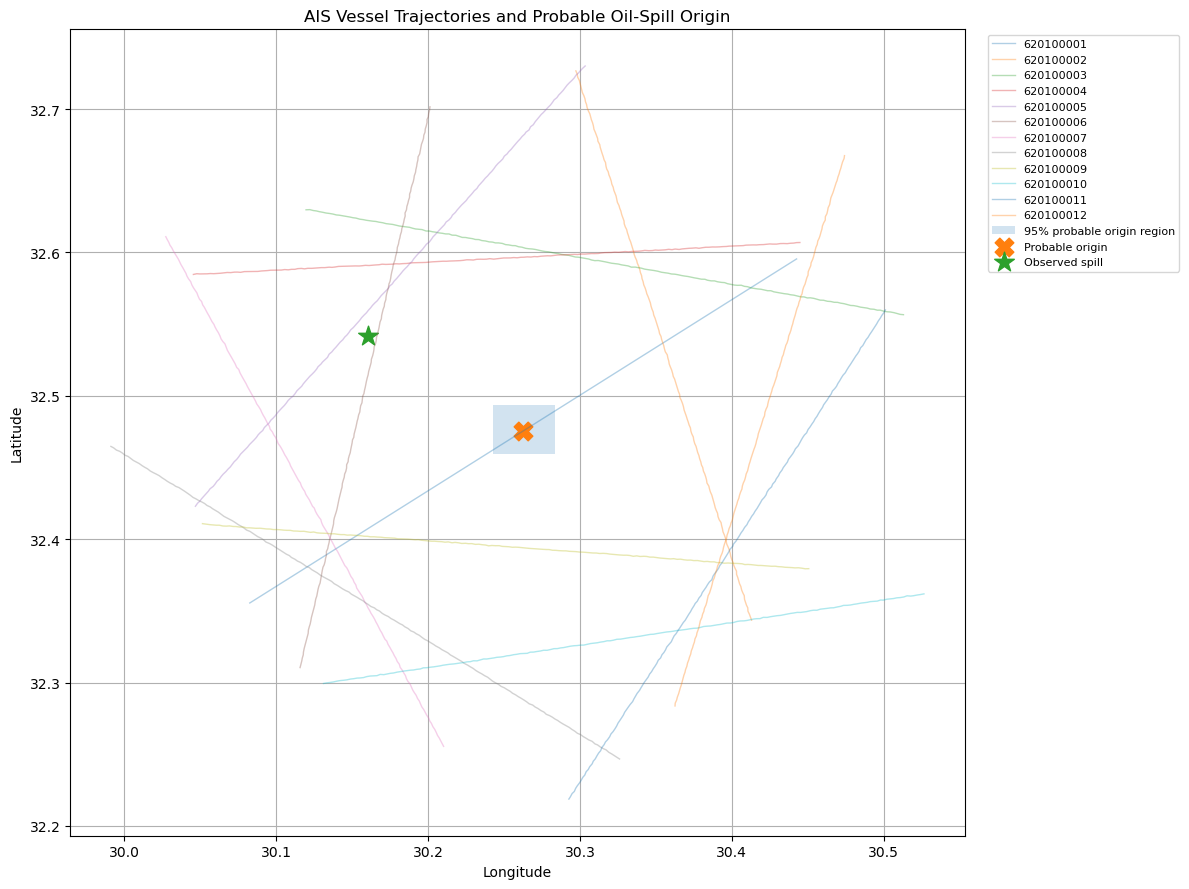

AIS TRAJECTORY VISUALIZATION
Observed spill : 32.541974 N, 30.160444 E
Probable origin: 32.475501 N, 30.262603 E
Origin region  : 32.459423 → 32.493904 N
                 30.243041 → 30.283669 E
Vessels plotted : 12


In [4]:
# Cell 4 — AIS Trajectory Visualization

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Phase 3 probable origin
# ---------------------------------------------------------

ensemble_lat = 32.475501
ensemble_lon = 30.262603

# 95% probable origin region
origin_bounds = {
    "min_latitude": 32.459423,
    "max_latitude": 32.493904,
    "min_longitude": 30.243041,
    "max_longitude": 30.283669
}

# ---------------------------------------------------------
# Observed spill location
# ---------------------------------------------------------

spill_lat = 32.541974
spill_lon = 30.160444

# ---------------------------------------------------------
# Create plot
# ---------------------------------------------------------

plt.figure(figsize=(12, 9))

# ---------------------------------------------------------
# Plot all vessel trajectories
# ---------------------------------------------------------

for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):

    plt.plot(
        vessel_df["longitude"],
        vessel_df["latitude"],
        linewidth=1.0,
        alpha=0.35,
        label=str(mmsi)
    )

# ---------------------------------------------------------
# Plot 95% probable origin region
# ---------------------------------------------------------

plt.fill(
    [
        origin_bounds["min_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["min_longitude"]
    ],
    [
        origin_bounds["min_latitude"],
        origin_bounds["min_latitude"],
        origin_bounds["max_latitude"],
        origin_bounds["max_latitude"]
    ],
    alpha=0.20,
    label="95% probable origin region"
)

# ---------------------------------------------------------
# Plot probable origin
# ---------------------------------------------------------

plt.scatter(
    ensemble_lon,
    ensemble_lat,
    marker="X",
    s=180,
    label="Probable origin"
)

# ---------------------------------------------------------
# Plot observed spill
# ---------------------------------------------------------

plt.scatter(
    spill_lon,
    spill_lat,
    marker="*",
    s=220,
    label="Observed spill"
)

# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "AIS Vessel Trajectories and Probable Oil-Spill Origin"
)

plt.grid(True)

# Keep legend readable
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print summary
# ---------------------------------------------------------

print("=" * 60)
print("AIS TRAJECTORY VISUALIZATION")
print("=" * 60)

print(
    f"Observed spill : "
    f"{spill_lat:.6f} N, {spill_lon:.6f} E"
)

print(
    f"Probable origin: "
    f"{ensemble_lat:.6f} N, {ensemble_lon:.6f} E"
)

print(
    f"Origin region  : "
    f"{origin_bounds['min_latitude']:.6f} → "
    f"{origin_bounds['max_latitude']:.6f} N"
)

print(
    f"                 "
    f"{origin_bounds['min_longitude']:.6f} → "
    f"{origin_bounds['max_longitude']:.6f} E"
)

print(
    f"Vessels plotted : "
    f"{synthetic_ais_df['mmsi'].nunique()}"
)

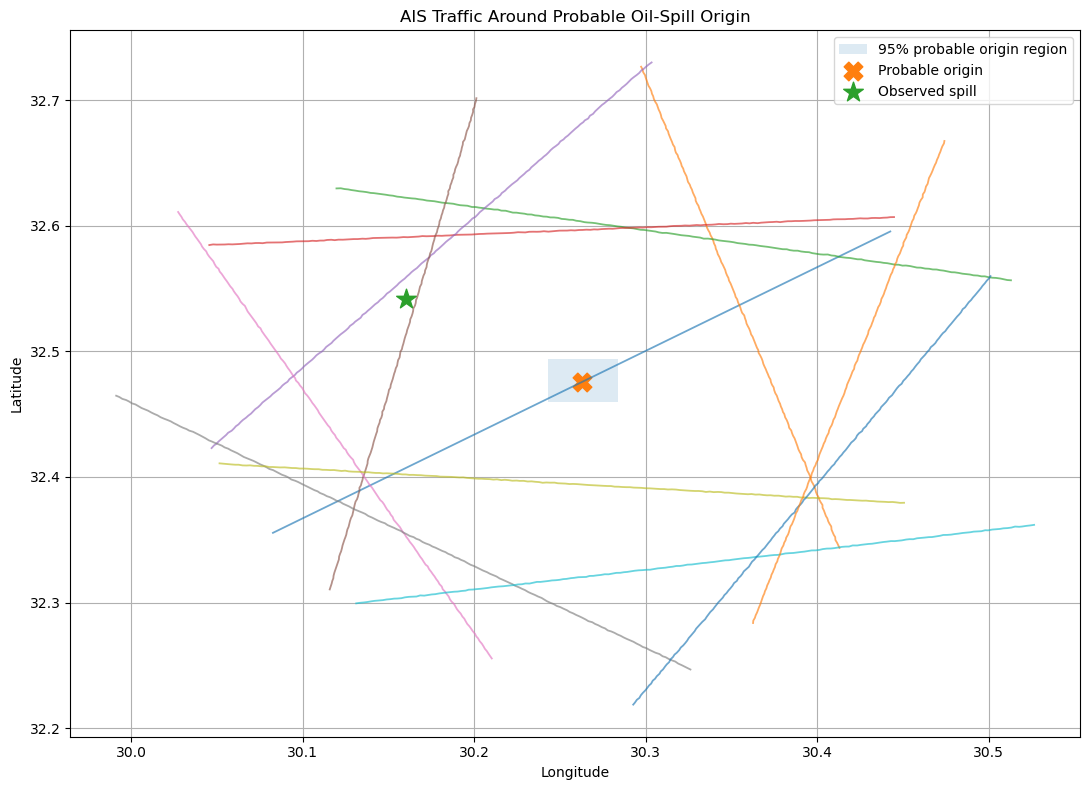

Observed spill:
  32.541974, 30.160444

Probable origin:
  32.475501, 30.262603

95% origin region:
  32.459423 → 32.493904 N
  30.243041 → 30.283669 E


In [5]:
# Cell 5 — Clean AIS sanity plot

import matplotlib.pyplot as plt

# Get Phase 3 origin directly from saved result
ensemble_lat = float(
    phase3_result["ensemble_origin"]["latitude"]
)

ensemble_lon = float(
    phase3_result["ensemble_origin"]["longitude"]
)

# Get observed spill directly from Phase 3 result
spill_lat = float(
    phase3_result["observation"]["latitude"]
)

spill_lon = float(
    phase3_result["observation"]["longitude"]
)

plt.figure(figsize=(11, 8))

# Vessel trajectories
for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):
    plt.plot(
        vessel_df["longitude"],
        vessel_df["latitude"],
        linewidth=1.3,
        alpha=0.65
    )

# 95% probable origin region
plt.fill(
    [
        origin_bounds["min_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["min_longitude"],
    ],
    [
        origin_bounds["min_latitude"],
        origin_bounds["min_latitude"],
        origin_bounds["max_latitude"],
        origin_bounds["max_latitude"],
    ],
    alpha=0.15,
    label="95% probable origin region"
)

# Probable origin
plt.scatter(
    ensemble_lon,
    ensemble_lat,
    marker="X",
    s=180,
    label="Probable origin"
)

# Observed spill
plt.scatter(
    spill_lon,
    spill_lat,
    marker="*",
    s=220,
    label="Observed spill"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AIS Traffic Around Probable Oil-Spill Origin")

plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Observed spill:")
print(f"  {spill_lat:.6f}, {spill_lon:.6f}")

print("\nProbable origin:")
print(f"  {ensemble_lat:.6f}, {ensemble_lon:.6f}")

print("\n95% origin region:")
print(
    f"  {origin_bounds['min_latitude']:.6f}"
    f" → "
    f"{origin_bounds['max_latitude']:.6f} N"
)

print(
    f"  {origin_bounds['min_longitude']:.6f}"
    f" → "
    f"{origin_bounds['max_longitude']:.6f} E"
)

In [6]:
# Cell 6 — AIS quality and trajectory sanity checks

print("AIS QUALITY CHECK")
print("=" * 50)

# 1. Missing values
print("\nMissing values:")
print(
    synthetic_ais_df[
        ["mmsi", "timestamp", "latitude",
         "longitude", "sog", "cog"]
    ].isna().sum()
)

# 2. Coordinate validity
print("\nCoordinate validity:")

invalid_lat = (
    (synthetic_ais_df["latitude"] < -90) |
    (synthetic_ais_df["latitude"] > 90)
).sum()

invalid_lon = (
    (synthetic_ais_df["longitude"] < -180) |
    (synthetic_ais_df["longitude"] > 180)
).sum()

print("Invalid latitude :", invalid_lat)
print("Invalid longitude:", invalid_lon)

# 3. Speed validity
print("\nSpeed statistics:")
print(
    synthetic_ais_df["sog"].describe()
)

print(
    "\nNegative SOG:",
    (synthetic_ais_df["sog"] < 0).sum()
)

# 4. Course validity
print("\nCOG range:")
print(
    f"{synthetic_ais_df['cog'].min():.2f}"
    f" → "
    f"{synthetic_ais_df['cog'].max():.2f} degrees"
)

# 5. Number of observations per vessel
print("\nObservations per vessel:")
print(
    synthetic_ais_df.groupby("mmsi").size()
)

# 6. Duplicate vessel/timestamp records
duplicates = synthetic_ais_df.duplicated(
    subset=["mmsi", "timestamp"]
).sum()

print(
    "\nDuplicate vessel/timestamp records:",
    duplicates
)

AIS QUALITY CHECK

Missing values:
mmsi         0
timestamp    0
latitude     0
longitude    0
sog          0
cog          0
dtype: int64

Coordinate validity:
Invalid latitude : 0
Invalid longitude: 0

Speed statistics:
count    2172.000000
mean        0.738968
std         0.087803
min         0.000000
25%         0.692303
50%         0.748596
75%         0.784734
max         0.942644
Name: sog, dtype: float64

Negative SOG: 0

COG range:
0.00 → 356.97 degrees

Observations per vessel:
mmsi
620100001    181
620100002    181
620100003    181
620100004    181
620100005    181
620100006    181
620100007    181
620100008    181
620100009    181
620100010    181
620100011    181
620100012    181
dtype: int64

Duplicate vessel/timestamp records: 0


In [7]:
# Cell 7 — Spatial candidate filtering around probable origin

import numpy as np
import pandas as pd

def haversine_vectorized(
    lat1,
    lon1,
    lat2,
    lon2
):
    """Calculate great-circle distance in km."""

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        2
        * R
        * np.arcsin(np.sqrt(a))
    )


# Calculate distance of every AIS observation
# from the Phase 3 probable origin center.

synthetic_ais_df["distance_to_origin_km"] = (
    haversine_vectorized(
        synthetic_ais_df["latitude"].values,
        synthetic_ais_df["longitude"].values,
        ensemble_lat,
        ensemble_lon,
    )
)

# Spatial candidate filter
candidate_points = synthetic_ais_df[
    synthetic_ais_df["distance_to_origin_km"]
    <= MAX_CANDIDATE_DISTANCE_KM
].copy()

# Candidate vessel IDs
candidate_mmsis = (
    candidate_points["mmsi"]
    .drop_duplicates()
    .tolist()
)

print("AIS spatial filtering")
print("=" * 50)

print(
    "Total AIS observations:",
    len(synthetic_ais_df)
)

print(
    "Observations within "
    f"{MAX_CANDIDATE_DISTANCE_KM} km:",
    len(candidate_points)
)

print(
    "Candidate vessels:",
    len(candidate_mmsis)
)

print("\nCandidate MMSIs:")
for mmsi in candidate_mmsis:
    vessel_type = (
        synthetic_ais_df.loc[
            synthetic_ais_df["mmsi"] == mmsi,
            "ship_type"
        ].iloc[0]
    )

    print(
        f"  {mmsi}  |  {vessel_type}"
    )

print("\nClosest AIS observations:")

print(
    candidate_points[
        [
            "mmsi",
            "timestamp",
            "latitude",
            "longitude",
            "sog",
            "cog",
            "distance_to_origin_km",
        ]
    ]
    .sort_values("distance_to_origin_km")
    .head(15)
)

AIS spatial filtering
Total AIS observations: 2172
Observations within 20.0 km: 1572
Candidate vessels: 12

Candidate MMSIs:
  620100001  |  Tanker
  620100002  |  Tanker
  620100003  |  Tanker
  620100004  |  Cargo
  620100005  |  Cargo
  620100006  |  Cargo
  620100007  |  Fishing
  620100008  |  Fishing
  620100009  |  Container
  620100010  |  Service
  620100011  |  Cargo
  620100012  |  Tanker

Closest AIS observations:
         mmsi                 timestamp   latitude  longitude       sog  \
90  620100001 2019-10-19 06:56:47+00:00  32.475501  30.262603  0.774698   
91  620100001 2019-10-19 07:06:47+00:00  32.476834  30.264603  0.774691   
89  620100001 2019-10-19 06:46:47+00:00  32.474168  30.260603  0.774705   
92  620100001 2019-10-19 07:16:47+00:00  32.478168  30.266603  0.774684   
88  620100001 2019-10-19 06:36:47+00:00  32.472834  30.258603  0.774712   
93  620100001 2019-10-19 07:26:47+00:00  32.479501  30.268603  0.774677   
87  620100001 2019-10-19 06:26:47+00:00  32.4

In [8]:
# Cell 8 — Calculate closest approach and timing for each vessel

candidate_stats = []

for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):

    vessel_df = vessel_df.sort_values("timestamp").copy()

    # Closest point to probable origin
    closest_idx = vessel_df[
        "distance_to_origin_km"
    ].idxmin()

    closest_row = vessel_df.loc[closest_idx]

    # Number of observations near origin
    near_origin_count = (
        vessel_df["distance_to_origin_km"]
        <= MAX_CANDIDATE_DISTANCE_KM
    ).sum()

    # Time spent within 20 km
    if near_origin_count > 0:
        near_origin_df = vessel_df[
            vessel_df["distance_to_origin_km"]
            <= MAX_CANDIDATE_DISTANCE_KM
        ]

        first_near = near_origin_df["timestamp"].min()
        last_near = near_origin_df["timestamp"].max()

        duration_hours = (
            last_near - first_near
        ).total_seconds() / 3600
    else:
        first_near = pd.NaT
        last_near = pd.NaT
        duration_hours = 0.0

    candidate_stats.append({
        "mmsi": mmsi,
        "ship_type": vessel_df["ship_type"].iloc[0],
        "min_distance_km": float(
            closest_row["distance_to_origin_km"]
        ),
        "closest_approach_time": closest_row["timestamp"],
        "closest_latitude": float(
            closest_row["latitude"]
        ),
        "closest_longitude": float(
            closest_row["longitude"]
        ),
        "sog_at_closest": float(
            closest_row["sog"]
        ),
        "cog_at_closest": float(
            closest_row["cog"]
        ),
        "points_within_20km": int(
            near_origin_count
        ),
        "duration_within_20km_hours": float(
            duration_hours
        ),
    })


candidate_stats_df = pd.DataFrame(
    candidate_stats
).sort_values(
    "min_distance_km"
).reset_index(drop=True)

print("Closest approach by vessel")
print("=" * 70)

print(
    candidate_stats_df[
        [
            "mmsi",
            "ship_type",
            "min_distance_km",
            "closest_approach_time",
            "sog_at_closest",
            "points_within_20km",
            "duration_within_20km_hours",
        ]
    ].to_string(index=False)
)

Closest approach by vessel
     mmsi ship_type  min_distance_km     closest_approach_time  sog_at_closest  points_within_20km  duration_within_20km_hours
620100001    Tanker         0.000000 2019-10-19 06:56:47+00:00        0.774698                 167                   27.666667
620100009 Container         9.019402 2019-10-19 06:36:47+00:00        0.746384                 171                   28.333333
620100002    Tanker        10.019938 2019-10-19 04:06:47+00:00        0.799003                 142                   23.500000
620100006     Cargo        10.193724 2019-10-19 07:46:47+00:00        0.798836                 140                   23.166667
620100005     Cargo        13.181717 2019-10-19 10:16:47+00:00        0.791449                 130                   21.500000
620100004     Cargo        13.437897 2019-10-19 05:56:47+00:00        0.676590                 142                   23.500000
620100003    Tanker        13.871567 2019-10-19 08:26:47+00:00        0.614591      

In [9]:
# Cell 9 — Multi-factor vessel attribution score

# ---------------------------------------------------------
# Temporal window
# ---------------------------------------------------------
# We don't assume an exact release timestamp.
# Instead, vessels approaching the inferred origin
# several hours before observation receive higher scores.

TEMPORAL_MIN_HOURS = 6
TEMPORAL_MAX_HOURS = 24

# ---------------------------------------------------------
# Score weights
# ---------------------------------------------------------

WEIGHT_DISTANCE = 0.60
WEIGHT_TIME = 0.25
WEIGHT_PERSISTENCE = 0.15


def distance_score(distance_km, max_distance_km):
    """
    Score based on distance from probable origin.
    1.0 = exactly at origin
    0.0 = at/above maximum candidate distance.
    """

    score = 1 - (
        distance_km / max_distance_km
    )

    return np.clip(score, 0, 1)


def temporal_score(
    closest_time,
    observation_time,
    min_hours=6,
    max_hours=24
):
    """
    Score how well closest approach timing fits
    the inferred spill-source window.

    Best score = 1 near the middle of the window.
    """

    hours_before = (
        observation_time - closest_time
    ).total_seconds() / 3600

    if (
        hours_before < min_hours
        or hours_before > max_hours
    ):
        return 0.0

    midpoint = (
        min_hours + max_hours
    ) / 2

    half_range = (
        max_hours - min_hours
    ) / 2

    score = 1 - (
        abs(hours_before - midpoint)
        / half_range
    )

    return float(
        np.clip(score, 0, 1)
    )


def persistence_score(
    duration_hours,
    max_duration
):
    """
    Normalize time spent near the origin.
    """

    if max_duration <= 0:
        return 0.0

    return float(
        np.clip(
            duration_hours / max_duration,
            0,
            1
        )
    )


# ---------------------------------------------------------
# Calculate scores
# ---------------------------------------------------------

scoring_df = candidate_stats_df.copy()

scoring_df["hours_before_observation"] = (
    observation_time
    - scoring_df["closest_approach_time"]
).dt.total_seconds() / 3600


scoring_df["distance_score"] = (
    scoring_df["min_distance_km"]
    .apply(
        lambda x:
        distance_score(
            x,
            MAX_CANDIDATE_DISTANCE_KM
        )
    )
)


scoring_df["temporal_score"] = (
    scoring_df["closest_approach_time"]
    .apply(
        lambda t:
        temporal_score(
            t,
            observation_time,
            TEMPORAL_MIN_HOURS,
            TEMPORAL_MAX_HOURS
        )
    )
)


max_duration = (
    scoring_df[
        "duration_within_20km_hours"
    ].max()
)

scoring_df["persistence_score"] = (
    scoring_df[
        "duration_within_20km_hours"
    ].apply(
        lambda x:
        persistence_score(
            x,
            max_duration
        )
    )
)


# ---------------------------------------------------------
# Final weighted attribution score
# ---------------------------------------------------------

scoring_df["attribution_score"] = (
    WEIGHT_DISTANCE
    * scoring_df["distance_score"]
    +
    WEIGHT_TIME
    * scoring_df["temporal_score"]
    +
    WEIGHT_PERSISTENCE
    * scoring_df["persistence_score"]
)

# Convert to percentage
scoring_df["attribution_score_pct"] = (
    scoring_df["attribution_score"] * 100
)

# Rank
scoring_df = scoring_df.sort_values(
    "attribution_score",
    ascending=False
).reset_index(drop=True)

scoring_df["rank"] = (
    scoring_df.index + 1
)


print("VESSEL ATTRIBUTION RANKING")
print("=" * 80)

print(
    scoring_df[
        [
            "rank",
            "mmsi",
            "ship_type",
            "min_distance_km",
            "hours_before_observation",
            "duration_within_20km_hours",
            "distance_score",
            "temporal_score",
            "persistence_score",
            "attribution_score_pct",
        ]
    ].to_string(index=False)
)

VESSEL ATTRIBUTION RANKING
 rank      mmsi ship_type  min_distance_km  hours_before_observation  duration_within_20km_hours  distance_score  temporal_score  persistence_score  attribution_score_pct
    1 620100001    Tanker         0.000000                  9.000000                   27.666667        1.000000        0.333333           0.976471              82.980392
    2 620100002    Tanker        10.019938                 11.833333                   23.500000        0.499003        0.648148           0.829412              58.585066
    3 620100009 Container         9.019402                  9.333333                   28.333333        0.549030        0.370370           1.000000              57.201053
    4 620100006     Cargo        10.193724                  8.166667                   23.166667        0.490314        0.240741           0.817647              47.702052
    5 620100004     Cargo        13.437897                 10.000000                   23.500000        0.328105      

In [10]:
# Cell 10 — Vessel trajectory behaviour features

trajectory_features = []

for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):

    vessel_df = vessel_df.sort_values(
        "timestamp"
    ).copy()

    # Speed statistics
    mean_sog = vessel_df["sog"].mean()
    max_sog = vessel_df["sog"].max()
    std_sog = vessel_df["sog"].std()

    # Course variability
    cog_std = vessel_df["cog"].std()

    # Total displacement
    start = vessel_df.iloc[0]
    end = vessel_df.iloc[-1]

    displacement_km = haversine_vectorized(
        start["latitude"],
        start["longitude"],
        end["latitude"],
        end["longitude"],
    )

    # Closest approach row
    closest_idx = vessel_df[
        "distance_to_origin_km"
    ].idxmin()

    closest_row = vessel_df.loc[
        closest_idx
    ]

    trajectory_features.append({
        "mmsi": mmsi,
        "mean_sog_knots": float(mean_sog),
        "max_sog_knots": float(max_sog),
        "sog_std_knots": float(std_sog),
        "cog_std_deg": float(cog_std),
        "total_displacement_km": float(
            displacement_km
        ),
        "closest_approach_sog": float(
            closest_row["sog"]
        ),
        "closest_approach_cog": float(
            closest_row["cog"]
        ),
    })


trajectory_features_df = pd.DataFrame(
    trajectory_features
)

print("VESSEL TRAJECTORY FEATURES")
print("=" * 80)

print(
    trajectory_features_df.to_string(
        index=False
    )
)

VESSEL TRAJECTORY FEATURES
     mmsi  mean_sog_knots  max_sog_knots  sog_std_knots  cog_std_deg  total_displacement_km  closest_approach_sog  closest_approach_cog
620100001        0.770414       0.775326       0.057584     3.841559              43.041988              0.774698             51.682321
620100002        0.796889       0.927647       0.077339    25.958322              43.962807              0.799003            340.950263
620100003        0.676548       0.787337       0.068109    21.498986              37.735528              0.614591            276.242720
620100004        0.675111       0.838059       0.069340    20.205009              37.488935              0.676590            259.566177
620100005        0.743533       0.857756       0.075115    16.412700              41.765122              0.791449            210.796528
620100006        0.793730       0.920368       0.079796    14.525117              44.229759              0.798836            184.528083
620100007        0.77

In [11]:
# Cell 11 — Vessel approach-direction consistency

approach_features = []

for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):

    vessel_df = vessel_df.sort_values(
        "timestamp"
    ).copy()

    closest_idx = vessel_df[
        "distance_to_origin_km"
    ].idxmin()

    closest_position = vessel_df.loc[
        closest_idx
    ]

    closest_pos_idx = vessel_df.index.get_loc(
        closest_idx
    )

    # Need at least one point before and after closest approach
    if (
        closest_pos_idx == 0
        or closest_pos_idx == len(vessel_df) - 1
    ):
        approach_features.append({
            "mmsi": mmsi,
            "approach_distance_change_km": np.nan,
            "departure_distance_change_km": np.nan,
            "approaching_origin": False,
            "leaving_origin": False,
        })
        continue

    before = vessel_df.iloc[
        closest_pos_idx - 1
    ]

    after = vessel_df.iloc[
        closest_pos_idx + 1
    ]

    # Distance change before closest approach
    # Negative = getting closer
    approach_distance_change = (
        closest_position["distance_to_origin_km"]
        - before["distance_to_origin_km"]
    )

    # Distance change after closest approach
    # Positive = moving away
    departure_distance_change = (
        after["distance_to_origin_km"]
        - closest_position["distance_to_origin_km"]
    )

    approaching_origin = (
        approach_distance_change < 0
    )

    leaving_origin = (
        departure_distance_change > 0
    )

    approach_features.append({
        "mmsi": mmsi,
        "approach_distance_change_km": float(
            approach_distance_change
        ),
        "departure_distance_change_km": float(
            departure_distance_change
        ),
        "approaching_origin": bool(
            approaching_origin
        ),
        "leaving_origin": bool(
            leaving_origin
        ),
    })


approach_features_df = pd.DataFrame(
    approach_features
)

print("VESSEL APPROACH BEHAVIOUR")
print("=" * 70)

print(
    approach_features_df.to_string(
        index=False
    )
)

VESSEL APPROACH BEHAVIOUR
     mmsi  approach_distance_change_km  departure_distance_change_km  approaching_origin  leaving_origin
620100001                    -0.239124                      0.239121                True            True
620100002                    -0.026298                      0.049238                True            True
620100003                    -0.031495                      0.022936                True            True
620100004                    -0.034324                      0.024626                True            True
620100005                    -0.009829                      0.023295                True            True
620100006                    -0.035028                      0.032422                True            True
620100007                    -0.042407                      0.041498                True            True
620100008                    -0.013755                      0.033022                True            True
620100009                    

In [12]:
# Cell 12 — Final multi-factor vessel attribution score

# Merge trajectory behaviour + approach behaviour
final_df = scoring_df.merge(
    trajectory_features_df,
    on="mmsi",
    how="left"
).merge(
    approach_features_df,
    on="mmsi",
    how="left"
)

# Approach consistency score
# 1.0 = vessel approached AND left the origin region
# 0.5 = only one direction is confirmed
# 0.0 = neither

final_df["approach_score"] = np.select(
    [
        (
            final_df["approaching_origin"]
            & final_df["leaving_origin"]
        ),
        (
            final_df["approaching_origin"]
            | final_df["leaving_origin"]
        ),
    ],
    [
        1.0,
        0.5,
    ],
    default=0.0
)

# Final weights
W_DISTANCE = 0.50
W_TIME = 0.20
W_PERSISTENCE = 0.20
W_APPROACH = 0.10

final_df["final_attribution_score"] = (
    W_DISTANCE
    * final_df["distance_score"]
    +
    W_TIME
    * final_df["temporal_score"]
    +
    W_PERSISTENCE
    * final_df["persistence_score"]
    +
    W_APPROACH
    * final_df["approach_score"]
)

final_df["final_score_pct"] = (
    final_df["final_attribution_score"] * 100
)

# Rank vessels
final_df = final_df.sort_values(
    "final_attribution_score",
    ascending=False
).reset_index(drop=True)

final_df["rank"] = (
    final_df.index + 1
)

print("FINAL VESSEL ATTRIBUTION RANKING")
print("=" * 100)

print(
    final_df[
        [
            "rank",
            "mmsi",
            "ship_type",
            "min_distance_km",
            "hours_before_observation",
            "duration_within_20km_hours",
            "approaching_origin",
            "leaving_origin",
            "distance_score",
            "temporal_score",
            "persistence_score",
            "approach_score",
            "final_score_pct",
        ]
    ].to_string(index=False)
)

FINAL VESSEL ATTRIBUTION RANKING
 rank      mmsi ship_type  min_distance_km  hours_before_observation  duration_within_20km_hours  approaching_origin  leaving_origin  distance_score  temporal_score  persistence_score  approach_score  final_score_pct
    1 620100001    Tanker         0.000000                  9.000000                   27.666667                True            True        1.000000        0.333333           0.976471             1.0        86.196078
    2 620100009 Container         9.019402                  9.333333                   28.333333                True            True        0.549030        0.370370           1.000000             1.0        64.858903
    3 620100002    Tanker        10.019938                 11.833333                   23.500000                True            True        0.499003        0.648148           0.829412             1.0        64.501353
    4 620100006     Cargo        10.193724                  8.166667                   23.166667   

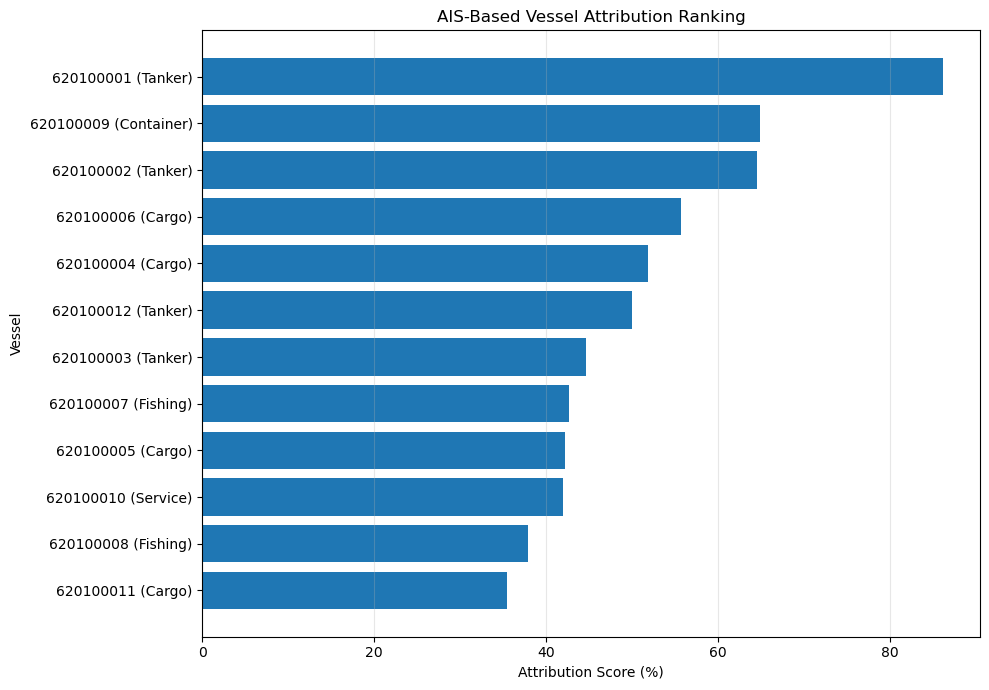

Top candidate:
MMSI       : 620100001
Ship type  : Tanker
Score      : 86.20%
Min distance: 0.000 km
Closest approach: 2019-10-19 06:56:47+00:00


In [13]:
# Cell 13 — Visualize final vessel attribution ranking

import matplotlib.pyplot as plt

plot_df = final_df.sort_values(
    "final_attribution_score",
    ascending=True
).copy()

labels = (
    plot_df["mmsi"].astype(str)
    + " ("
    + plot_df["ship_type"]
    + ")"
)

plt.figure(figsize=(10, 7))

plt.barh(
    labels,
    plot_df["final_score_pct"]
)

plt.xlabel("Attribution Score (%)")
plt.ylabel("Vessel")
plt.title("AIS-Based Vessel Attribution Ranking")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("Top candidate:")
top_candidate = final_df.iloc[0]

print(
    f"MMSI       : {top_candidate['mmsi']}"
)

print(
    f"Ship type  : {top_candidate['ship_type']}"
)

print(
    f"Score      : "
    f"{top_candidate['final_score_pct']:.2f}%"
)

print(
    f"Min distance: "
    f"{top_candidate['min_distance_km']:.3f} km"
)

print(
    f"Closest approach: "
    f"{top_candidate['closest_approach_time']}"
)

In [14]:
# Cell 14 — Save final AIS attribution result

import json

top_candidate = final_df.iloc[0]

# Convert ranking table into JSON-safe records
ranking_records = []

for _, row in final_df.iterrows():

    ranking_records.append({
        "rank": int(row["rank"]),
        "mmsi": int(row["mmsi"]),
        "ship_type": str(row["ship_type"]),

        "attribution_score_pct": float(
            row["final_score_pct"]
        ),

        "minimum_distance_km": float(
            row["min_distance_km"]
        ),

        "closest_approach_time": str(
            row["closest_approach_time"]
        ),

        "hours_before_observation": float(
            row["hours_before_observation"]
        ),

        "duration_within_20km_hours": float(
            row["duration_within_20km_hours"]
        ),

        "approaching_origin": bool(
            row["approaching_origin"]
        ),

        "leaving_origin": bool(
            row["leaving_origin"]
        ),

        "scores": {
            "distance": float(
                row["distance_score"]
            ),
            "temporal": float(
                row["temporal_score"]
            ),
            "persistence": float(
                row["persistence_score"]
            ),
            "approach": float(
                row["approach_score"]
            ),
        },
    })


phase4_result = {
    "investigation": {
        "observation_timestamp": str(
            observation_time
        ),

        "observed_spill": {
            "latitude": float(spill_lat),
            "longitude": float(spill_lon),
        },

        "probable_origin": {
            "latitude": float(ensemble_lat),
            "longitude": float(ensemble_lon),
        },

        "origin_region_95_percent": {
            "min_latitude": float(
                origin_bounds["min_latitude"]
            ),
            "max_latitude": float(
                origin_bounds["max_latitude"]
            ),
            "min_longitude": float(
                origin_bounds["min_longitude"]
            ),
            "max_longitude": float(
                origin_bounds["max_longitude"]
            ),
        },
    },

    "ais_analysis": {
        "data_type": "synthetic",
        "vessel_count": int(
            synthetic_ais_df["mmsi"].nunique()
        ),
        "ais_observation_count": int(
            len(synthetic_ais_df)
        ),
        "spatial_threshold_km": float(
            MAX_CANDIDATE_DISTANCE_KM
        ),
    },

    "top_candidate": {
        "mmsi": int(
            top_candidate["mmsi"]
        ),
        "ship_type": str(
            top_candidate["ship_type"]
        ),
        "score_pct": float(
            top_candidate["final_score_pct"]
        ),
    },

    "ranking": ranking_records,

    "scoring_weights": {
        "distance": W_DISTANCE,
        "temporal": W_TIME,
        "persistence": W_PERSISTENCE,
        "approach": W_APPROACH,
    },
}


PHASE4_RESULT_PATH = (
    BASE / "phase4_ais_attribution_result.json"
)

with open(
    PHASE4_RESULT_PATH,
    "w"
) as f:
    json.dump(
        phase4_result,
        f,
        indent=2
    )


print("Phase 4 result saved:")
print(PHASE4_RESULT_PATH)

print("\n" + "=" * 60)
print("PHASE 4 — AIS ATTRIBUTION SUMMARY")
print("=" * 60)

print(
    f"Top candidate : "
    f"{top_candidate['mmsi']}"
)

print(
    f"Ship type     : "
    f"{top_candidate['ship_type']}"
)

print(
    f"Score         : "
    f"{top_candidate['final_score_pct']:.2f}%"
)

print(
    f"Closest point : "
    f"{top_candidate['min_distance_km']:.3f} km"
)

print(
    f"Approach time : "
    f"{top_candidate['closest_approach_time']}"
)

Phase 4 result saved:
/Volumes/Utkash SSD/SIH26143/phase4_ais_attribution_result.json

PHASE 4 — AIS ATTRIBUTION SUMMARY
Top candidate : 620100001
Ship type     : Tanker
Score         : 86.20%
Closest point : 0.000 km
Approach time : 2019-10-19 06:56:47+00:00


In [15]:
# Cell 15 — Validate attribution ranking against synthetic ground truth

# Ground-truth vessel used ONLY for validation.
# The scoring engine itself never receives this information.
GROUND_TRUTH_MMSI = 620100001

top_ranked_mmsi = int(
    final_df.iloc[0]["mmsi"]
)

ground_truth_rank = int(
    final_df.index[
        final_df["mmsi"] == GROUND_TRUTH_MMSI
    ][0]
) + 1

top1_correct = (
    top_ranked_mmsi == GROUND_TRUTH_MMSI
)

# Score separation from second-ranked vessel
top_score = float(
    final_df.iloc[0]["final_score_pct"]
)

second_score = float(
    final_df.iloc[1]["final_score_pct"]
)

score_margin = top_score - second_score

print("PHASE 4 ATTRIBUTION VALIDATION")
print("=" * 60)

print(
    f"Ground-truth vessel : {GROUND_TRUTH_MMSI}"
)

print(
    f"Predicted top vessel: {top_ranked_mmsi}"
)

print(
    f"Ground-truth rank   : #{ground_truth_rank}"
)

print(
    f"Top-1 correct       : {top1_correct}"
)

print(
    f"Top score           : {top_score:.2f}%"
)

print(
    f"Second score        : {second_score:.2f}%"
)

print(
    f"Score margin        : {score_margin:.2f} percentage points"
)

if top1_correct:
    print("\n✅ Synthetic attribution test PASSED")
else:
    print("\n❌ Synthetic attribution test FAILED")

PHASE 4 ATTRIBUTION VALIDATION
Ground-truth vessel : 620100001
Predicted top vessel: 620100001
Ground-truth rank   : #1
Top-1 correct       : True
Top score           : 86.20%
Second score        : 64.86%
Score margin        : 21.34 percentage points

✅ Synthetic attribution test PASSED


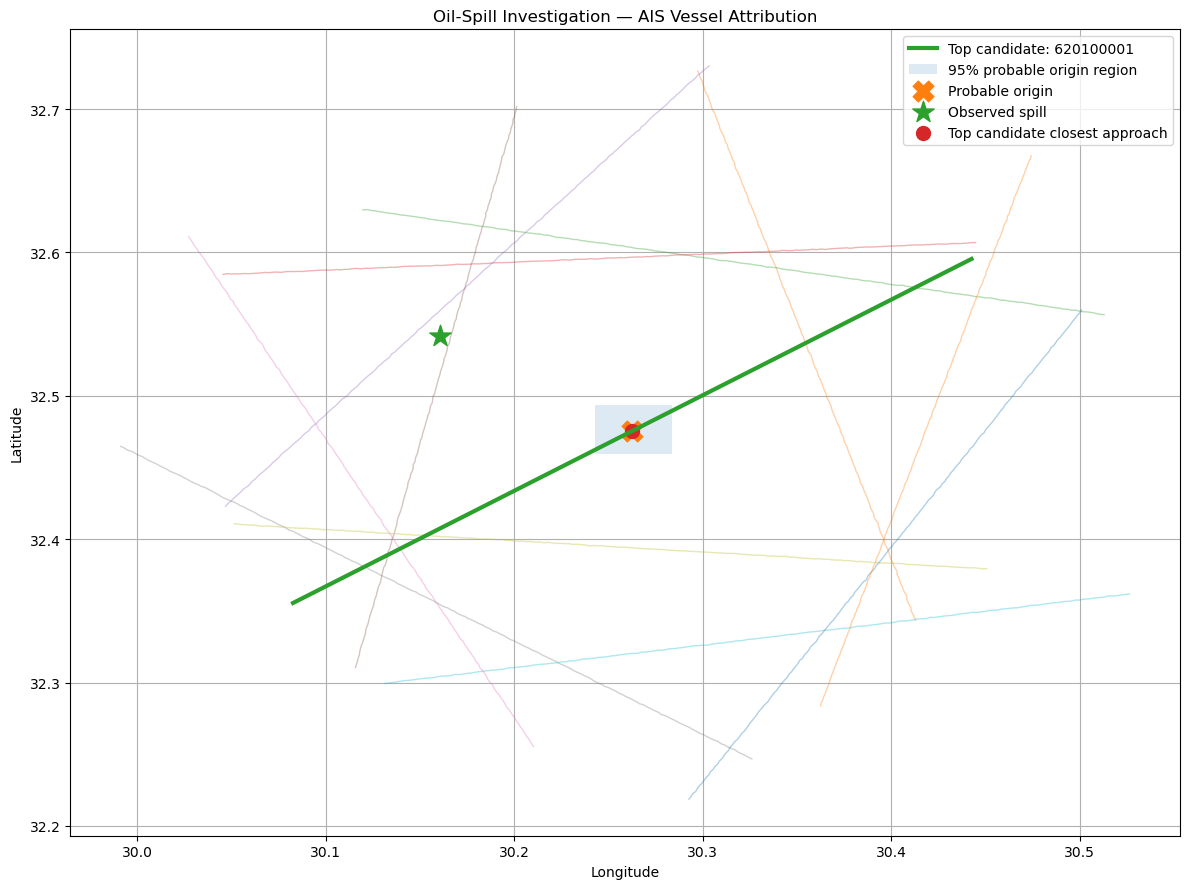

FINAL AIS INVESTIGATION
Top candidate MMSI : 620100001
Ship type           : Tanker
Attribution score   : 86.20%
Closest approach    : 0.000 km
Approach timestamp  : 2019-10-19 06:56:47+00:00
Probable origin     : 32.475501, 30.262603


In [16]:
# Cell 16 — Final AIS Investigation Map

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

# ---------------------------------------------------------
# Plot all vessel trajectories
# ---------------------------------------------------------

for mmsi, vessel_df in synthetic_ais_df.groupby("mmsi"):

    plt.plot(
        vessel_df["longitude"],
        vessel_df["latitude"],
        linewidth=1.0,
        alpha=0.35
    )

# ---------------------------------------------------------
# Highlight top-ranked vessel
# ---------------------------------------------------------

top_mmsi = int(final_df.iloc[0]["mmsi"])

top_vessel_df = synthetic_ais_df[
    synthetic_ais_df["mmsi"] == top_mmsi
].sort_values("timestamp")

plt.plot(
    top_vessel_df["longitude"],
    top_vessel_df["latitude"],
    linewidth=3,
    label=f"Top candidate: {top_mmsi}"
)

# ---------------------------------------------------------
# 95% probable origin region
# ---------------------------------------------------------

plt.fill(
    [
        origin_bounds["min_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["max_longitude"],
        origin_bounds["min_longitude"],
    ],
    [
        origin_bounds["min_latitude"],
        origin_bounds["min_latitude"],
        origin_bounds["max_latitude"],
        origin_bounds["max_latitude"],
    ],
    alpha=0.15,
    label="95% probable origin region"
)

# ---------------------------------------------------------
# Probable origin
# ---------------------------------------------------------

plt.scatter(
    ensemble_lon,
    ensemble_lat,
    marker="X",
    s=220,
    label="Probable origin"
)

# ---------------------------------------------------------
# Observed spill
# ---------------------------------------------------------

plt.scatter(
    spill_lon,
    spill_lat,
    marker="*",
    s=260,
    label="Observed spill"
)

# ---------------------------------------------------------
# Closest approach point of top candidate
# ---------------------------------------------------------

top_closest = final_df.iloc[0]

plt.scatter(
    top_closest["closest_longitude"],
    top_closest["closest_latitude"],
    marker="o",
    s=100,
    label="Top candidate closest approach"
)

# ---------------------------------------------------------
# Labels and formatting
# ---------------------------------------------------------

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Oil-Spill Investigation — AIS Vessel Attribution"
)

plt.legend(
    loc="best"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# Final investigation summary
# ---------------------------------------------------------

print("=" * 65)
print("FINAL AIS INVESTIGATION")
print("=" * 65)

print(
    f"Top candidate MMSI : {top_mmsi}"
)

print(
    f"Ship type           : "
    f"{top_closest['ship_type']}"
)

print(
    f"Attribution score   : "
    f"{top_closest['final_score_pct']:.2f}%"
)

print(
    f"Closest approach    : "
    f"{top_closest['min_distance_km']:.3f} km"
)

print(
    f"Approach timestamp  : "
    f"{top_closest['closest_approach_time']}"
)

print(
    f"Probable origin     : "
    f"{ensemble_lat:.6f}, {ensemble_lon:.6f}"
)

In [17]:
# Final summary

print("=" * 65)
print("FINAL AIS INVESTIGATION")
print("=" * 65)

print(
    f"Top candidate MMSI : {top_mmsi}"
)

print(
    f"Ship type           : "
    f"{top_closest['ship_type']}"
)

print(
    f"Attribution score   : "
    f"{top_closest['final_score_pct']:.2f}%"
)

print(
    f"Closest approach    : "
    f"{top_closest['min_distance_km']:.3f} km"
)

print(
    f"Approach timestamp  : "
    f"{top_closest['closest_approach_time']}"
)

print(
    f"Probable origin     : "
    f"{ensemble_lat:.6f}, {ensemble_lon:.6f}"
)

FINAL AIS INVESTIGATION
Top candidate MMSI : 620100001
Ship type           : Tanker
Attribution score   : 86.20%
Closest approach    : 0.000 km
Approach timestamp  : 2019-10-19 06:56:47+00:00
Probable origin     : 32.475501, 30.262603
